Estudiante: Scarlett Cedeño

**Carga del dataset**

In [2]:
# Dataset: Breast Cancer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, classification_report)
from sklearn.preprocessing import StandardScaler

#Preparacion del dataset
data = load_breast_cancer()
X, y = data.data, data.target  # X: caracteristicas, y: etiquetas (0=maligno, 1=benigno)

#Escalar  datos para mejorar el rendimiento de la Regresion Logistica
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#División en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
#Se empieza a entrenar el modelo
model = LogisticRegression(max_iter=10000, random_state=50)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Probabilidades para AUC-ROC

**Matriz de Confusion**

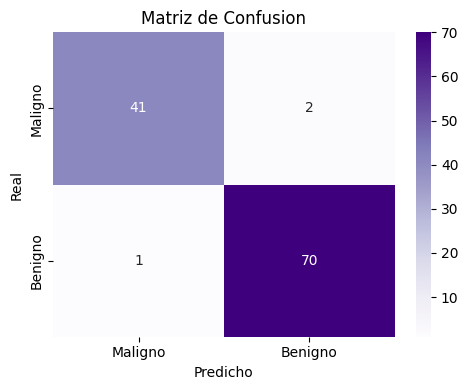


 Matriz de Confusion
Verdaderos Negativos (Maligno correcto): 41
Falsos Positivos (Maligno predicho como Benigno): 2
Falsos Negativos (Benigno predicho como Maligno): 1
Verdaderos Positivos (Benigno correcto): 70


In [8]:
#Matriz de confusion comparando las etiquetas reales (y_test) contra las predicciones del modelo (y_pred)
#Tiene 4 celdas: VN, FP, FN, VP
cm = confusion_matrix(y_test, y_pred)

#mapa de calor para visualizar la matriz
plt.figure(figsize=(5, 4))

#annot=True: muestra los numeros dentro de cada celda
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Maligno', 'Benigno'],
            yticklabels=['Maligno', 'Benigno'])

plt.title('Matriz de Confusion')
plt.ylabel('Real')      # Eje Y: lo que realmente era
plt.xlabel('Predicho')  # Eje X: lo que el modelo predijo
plt.tight_layout()
plt.show()

#Imprimimos cada valor de la matriz de forma individual y explicada
print("\n Matriz de Confusion")
print(f"Verdaderos Negativos (Maligno correcto): {cm[0,0]}") #Verdaderos Negativos
print(f"Falsos Positivos (Maligno predicho como Benigno): {cm[0,1]}") #Falsos Positivos
print(f"Falsos Negativos (Benigno predicho como Maligno): {cm[1,0]}") #Falsos Negativos
print(f"Verdaderos Positivos (Benigno correcto): {cm[1,1]}") #Verdaderos Positivos

**Metricas de Evaluacion**

In [9]:
#Recall: de todos los casos positivos reales, cuantos detecto correctamente el modelo
recall = recall_score(y_test, y_pred)

#F1-Score: media entre Precision y Recall
f1     = f1_score(y_test, y_pred)

#Se calcula sobre las probabilidades (y_prob) y no sobre las predicciones directas (y_pred)
auc    = roc_auc_score(y_test, y_prob)

# Mostramos los resultados de las 3 metricas con 4 decimales de precision
print("\n Metricas de Evaluacion")
print(f"Recall     : {recall:.4f}")  # Que tan bien detecta los positivos reales
print(f"F1-Score   : {f1:.4f}")      # Equilibrio entre Precision y Recall
print(f"AUC-ROC    : {auc:.4f}")     # Capacidad general de discriminacion del modelo


 Metricas de Evaluacion
Recall     : 0.9859
F1-Score   : 0.9790
AUC-ROC    : 0.9974


**K-FOLD CROSS-VALIDATION**

In [13]:
#Probamos dos configuraciones de K-Fold: k=5 y k=10
#k=5: divide los datos en 5 partes, entrena 5 veces usando 4 partes y evalua con 1
#k=10: mas particiones, estimacion mas precisa pero mayor tiempo de computo
for k in [5, 10]:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    #Calculamos cada metrica promediada sobre todos los folds
    scores_recall = cross_val_score(model, X_scaled, y, cv=kf, scoring='recall')
    scores_f1     = cross_val_score(model, X_scaled, y, cv=kf, scoring='f1')
    scores_auc    = cross_val_score(model, X_scaled, y, cv=kf, scoring='roc_auc')

    #Mostramos el promedio y la desviacion estandar de cada metrica
    print(f"\nK-Fold k={k}")
    print(f"  Recall   promedio: {scores_recall.mean():.4f} | Desviacion: {scores_recall.std():.4f}")
    print(f"  F1-Score promedio: {scores_f1.mean():.4f} | Desviacion: {scores_f1.std():.4f}")
    print(f"  AUC-ROC  promedio: {scores_auc.mean():.4f} | Desviacion: {scores_auc.std():.4f}")


K-Fold k=5
  Recall   promedio: 0.9862 | Desviacion: 0.0082
  F1-Score promedio: 0.9818 | Desviacion: 0.0073
  AUC-ROC  promedio: 0.9948 | Desviacion: 0.0055

K-Fold k=10
  Recall   promedio: 0.9857 | Desviacion: 0.0144
  F1-Score promedio: 0.9794 | Desviacion: 0.0176
  AUC-ROC  promedio: 0.9941 | Desviacion: 0.0082


**Optimizacion de Hiperparámetros**

In [14]:
#Definimos el espacio de busqueda de hiperparametros
#C: controla la regularizacion, valores bajos = mas regularizacion, valores altos = menos
#solver: algoritmo de optimizacion interno de la Regresion Logistica
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

#GridSearchCV prueba todas las combinaciones posibles del param_grid - 10 combinaciones
#cv=5: usa validacion cruzada de 5 folds para evaluar cada combinacion
#scoring='recall': optimiza buscando el mejor Recall
grid_search = GridSearchCV(LogisticRegression(max_iter=10000), param_grid, cv=5, scoring='recall')
grid_search.fit(X_train, y_train)
print(f"\nGridSearchCV       - Mejores parametros: {grid_search.best_params_} | Recall: {grid_search.best_score_:.4f}")

#RandomizedSearchCV prueba solo n_iter=6 combinaciones aleatorias del param_grid
#Es mas rapido que GridSearchCV cuando el espacio de busqueda es muy grande
random_search = RandomizedSearchCV(LogisticRegression(max_iter=10000), param_grid, cv=5,
                                   scoring='recall', n_iter=6, random_state=50)
random_search.fit(X_train, y_train)
print(f"RandomizedSearchCV - Mejores parametros: {random_search.best_params_} | Recall: {random_search.best_score_:.4f}")


GridSearchCV       - Mejores parametros: {'C': 0.01, 'solver': 'lbfgs'} | Recall: 0.9966
RandomizedSearchCV - Mejores parametros: {'solver': 'lbfgs', 'C': 0.1} | Recall: 0.9966


**Ajuste de umbral y Curva ROC**

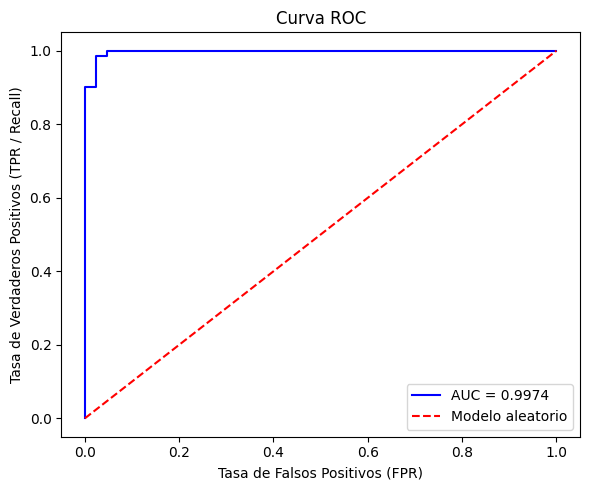


--- Impacto del Umbral en las Metricas ---
Umbral     Recall     F1-Score  
0.3        1.0000     0.9861    
0.5        0.9859     0.9790    
0.7        0.9437     0.9640    


In [19]:
#Calculamos los puntos de la curva ROC variando el umbral de decision
#fpr: tasa de falsos positivos en cada umbral
#tpr: tasa de verdaderos positivos (Recall) en cada umbral
#thresholds: valores de umbral evaluados
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

#Graficamos la curva ROC
plt.figure(figsize=(6, 5))
#entre mas cerca al punto (0,1), mejor es el modelo
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc:.4f}')
#Linea diagonal: representa un modelo aleatorio (AUC = 0.5), referencia base
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Modelo aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title('Curva ROC')
plt.legend()
plt.tight_layout()
plt.show()

#Analizamos como cambian Recall y F1-Score al variar el umbral de decision
#Umbral 0.3: mas permisivo, detecta mas positivos pero puede generar mas falsos positivos
#Umbral 0.5: umbral por defecto del modelo
#Umbral 0.7: mas estricto, menos falsos positivos pero puede perder positivos reales
print("\n--- Impacto del Umbral en las Metricas ---")
print(f"{'Umbral':<10} {'Recall':<10} {'F1-Score':<10}")
for thresh in [0.3, 0.5, 0.7]:
    # Convertimos probabilidades a predicciones binarias segun el umbral actual
    y_pred_thresh = (y_prob >= thresh).astype(int)
    r = recall_score(y_test, y_pred_thresh, zero_division=0)
    f = f1_score(y_test, y_pred_thresh, zero_division=0)
    print(f"{thresh:<10} {r:<10.4f} {f:<10.4f}")